# 2026-09-09 More Newton

## Last time

* Newton's method via Taylor series
* Convergence theory for fixed point methods
* Derive Newton's method via fixed point convergence theory

## Today

* Newton methods in computing culture
* Breaking Newton's method
* Exploration
* Finding mutiple roots
* Conditioning of rootfinding problems

In [1]:
using Plots
default(linewidth=3, legendfontsize=12)

function newton(f, fp, x0; tol=1e-8, verbose=false)
    x = x0
    for k in 1:100 # max number of iterations
        fx = f(x)
        fpx = fp(x)
        if verbose
            println("[$k] x=$x  f(x)=$fx  f'(x)=$fpx")
        end
        if abs(fx) < tol
            return x, fx, k
        end
        x = x - fx / fpx
    end  
end

function newton_hist(f, fp, x0; tol=1e-12)
    x = x0
    hist = []
    for k in 1:100 # max number of iterations
        fx = f(x)
        fpx = fp(x)
        push!(hist, [x fx fpx])
        if abs(fx) < tol
            return vcat(hist...)
        end
        x = x - fx / fpx
    end
end

f(x) = cos(x) - x
fp(x) = -sin(x) - 1

fp (generic function with 1 method)

# A fresh derivation of Newton's method

* A rootfinding problem $f(x) = 0$ can be converted to a fixed point problem $$x = x + f(x) =: g(x)$$ but there is no guarantee that $g'(x_*) = 1 + f'(x_*)$ will have magnitude less than 1.
* Problem-specific algebraic manipulation can be used to make $|g'(x_*)|$ small.
* $x = x + h(x) f(x)$ is also a valid formulation for any $h(x)$ bounded away from $0$.
* Can we choose $h(x)$ such that $$ g'(x) = 1 + h'(x) f(x) + h(x) f'(x) = 0$$ when $f(x) = 0$?

In other words,
$$ x_{k+1} = x_k + \underbrace{\frac{-1}{f'(x_k)}}_{h(x_k)} f(x_k)  . $$

# Quadratic convergence!

$$ \left\lvert \frac{e_{k+1}}{e_k} \right\rvert \to \lvert g'(x_*) \rvert $$

* What does it mean that $g'(x_*) = 0$?
* It turns out that Newton's method has _locally quadratic_ convergence to simple roots,
$$\lim_{k \to \infty} \frac{|e_{k+1}|}{|e_k|^2} < \infty.$$
* "The number of correct digits doubles each iteration."
* Now that we know how to make a good guess accurate, the effort lies in getting a good guess.

# Culture: fast inverse square root

The following code appeared literally (including comments) in the Quake III Arena source code (late 1990s).

```c
float Q_rsqrt( float number )
{
	long i;
	float x2, y;
	const float threehalfs = 1.5F;

	x2 = number * 0.5F;
	y  = number;
	i  = * ( long * ) &y;                       // evil floating point bit level hacking
	i  = 0x5f3759df - ( i >> 1 );               // what the fuck? 
	y  = * ( float * ) &i;
    y  = y * ( threehalfs - ( x2 * y * y ) );   // 1st iteration
//  y  = y * ( threehalfs - ( x2 * y * y ) );   // 2nd iteration, this can be removed

	return y;
}
```

We now have [vector instructions](https://software.intel.com/sites/landingpage/IntrinsicsGuide/#text=rsqrt&expand=2989,1224,4470) for approximate inverse square root.
More at https://en.wikipedia.org/wiki/Fast_inverse_square_root

# How does it work?

Let's look at the last line
```c
y  = y * ( threehalfs - ( x2 * y * y ) );   // 1st iteration
```

We want a function $f(y)$ such that $f(1/\sqrt{x}) = 0$. One such function is
$$ f(y) = 1/y^2 - x, \quad f'(y) = -2/y^3.$$

There are others, e.g.,
$$f_1(y) = y^2 - 1/x,\quad f'(y) = 2 y,$$
but this would require a division.

Newton's method is
\begin{align}
y_{k+1} &= y_k - \frac{f(y_k)}{f'(y_k)} \\
&= y_k - \frac{1/y_k^2 - x}{-2/y_k^3} \\
&= y_k + \frac 1 2 (y_k - x y_k^3) \\
&= y_k \left(\frac 3 2 - \frac 1 2 x y_k^2\right)
\end{align}

# Rootfinding methods outlook

* Newton methods are immensely successful
  * Convergence theory is local; we need good initial guesses (activity)
  * Computing the derivative $f'(x)$ is *intrusive*
    * Avoided by secant methods (approximate the derivative; activity)
    * Algorithmic or numerical differentiation (future topics)
  * Bisection is robust when conditions are met
  * Line search (activity)
  * When does Newton diverge?

* More topics
  * Find *all* the roots
  * Use Newton-type methods with bounds
  * Times when Newton converges slowly

# Exploratory rootfinding

* Find a function $f(x)$ that models something you're interested in. You could consider nonlinear physical models (aerodynamic drag, nonlinear elasticity), behavioral models, probability distributions, or anything else that that catches your interest. Implement the function in Julia or another language.

* Consider how you might know the output of such functions, but not an input. Think from the position of different stakeholders: is the equation used differently by an experimentalist collecting data versus by someone making predictions through simulation? How about a company or government reasoning about people versus the people their decisions may impact?

* Formulate the map from known to desired data as a rootfinding problem and try one or more methods (Newton, bisection, etc., or use a rootfinding library).

* Plot the inverse function (output versus input) from the standpoint of one or more stakeholder. Are there interesting inflection points? Are the methods reliable?

* If there are a hierarchy of models for the application you're interested in, consider using a simpler model to provide an initial guess to a more complicated model.

# Equation of state example

Consider an [equation of state](https://en.wikipedia.org/wiki/Real_gas#Beattie%E2%80%93Bridgeman_model) for a real gas, which might provide pressure $p(T, \rho)$ as a function of temperature $T$ and density $\rho = 1/v$.

* An experimentalist can measure temperature and pressure, and will need to solve for density (which is difficult to measure directly).
* A simulation might know (at each cell or mesh point, at each time step) the density and internal energy, and need to compute pressure (and maybe temperature).
* An analyst might have access to simulation output and wish to compute entropy (a thermodynamic property whose change reflects irreversible processes, and can be used to assess accuracy/stability of a simulation or efficiency of a machine).

The above highlights how many equations are incomplete, failing to model how related quantities (internal energy and entropy in this case) depend on the other quantities. Standardization bodies (such as NIST, here in Boulder) and practitioners often prefer models that intrinsically provide a complete set of consistent relations. An elegent methodology for equations of state for gasses and fluids is by way of the [Helmholtz free energy](http://www.coolprop.org/fluid_properties/PurePseudoPure.html#pure-and-pseudo-pure-fluid-properties), which is not observable, but whose partial derivatives define a complete set of thermodynamic properties. The [CoolProp](http://www.coolprop.org) software has highly accurate models for many gasses, and practitioners often build less expensive models for narrower ranges of theromdynamic conditions.

# Roots with multiplicity

There are multiple ways to represent (monic) polynomials

\begin{align}
f(x) &= (x - a_1) (x - a_2) & g(x) &= x^2 \underbrace{- (a_1 + a_2)}_{b_1} x + \underbrace{a_1 a_2}_{b_2}
\end{align}

In [2]:
poly_eval_prod(x, a) = prod(x .- a)
function poly_eval_sum(x, b)
    sum = 1
    for c in b
        # This is known as Horner's rule
        sum = x * sum + c
    end
    sum
end

eps = 1e-10
a = [1e5, 1e5*(1+eps)] # tiny perturbation to root
b = [-(a[1] + a[2])*(1+eps), # tiny perturbation to monomial coefficent
    a[1]*a[2]]
f(x) = poly_eval_prod(x, a)
g(x) = poly_eval_sum(x, b)

g (generic function with 1 method)

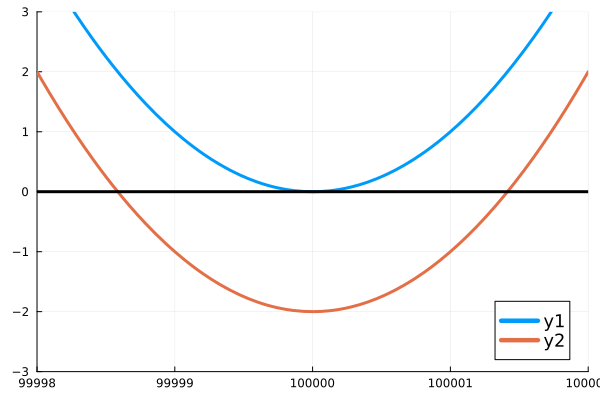

In [3]:
plot([f, g], xlim=(a[1]-2, a[2]+2), ylim=(-3, 3))
plot!(zero, color=:black, label=:none)

* Perturbing the coefficient in the tenth digit made the difference between one root and two.
* The distance between the roots was big when $b_1$ was perturbed.

# How did the roots move?
Take two roots at $x=a$ and perturb the middle coefficient.
\begin{align}
x^2 \underbrace{- 2a(1 + \epsilon)}_{b_1} x + \underbrace{a^2}_{b_2} = 0
\end{align}

Analytically, we know the roots are at

\begin{align}
\frac{b_1}{2} \pm \sqrt{\frac{b_1^2}{4} - b_2} 
&= a(1+\epsilon) \pm \sqrt{a^2(1+\epsilon)^2 - a^2} \\
&= a(1+\epsilon) \pm a \sqrt{2 \epsilon + \epsilon^2} \\
&\approx a \Bigl(1 + \epsilon \pm \sqrt{2 \epsilon} \Bigr).
\end{align}

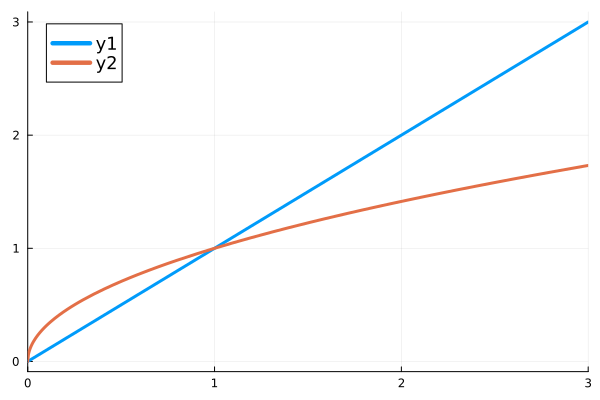

In [4]:
plot([x->x, sqrt], xlims=(0, 3))

Note that condition number is well behaved.
$$ \kappa(\sqrt{\epsilon}) = \frac{1}{2\sqrt{\epsilon}} \frac{\epsilon}{\sqrt{\epsilon}} = \frac 1 2$$

# What does Newton find?

In [5]:
hist = newton_hist(g, x -> 2*x + b[1], 1.1e5; tol=1e-14)

17×3 Matrix{Float64}:
 110000.0            1.0e8       20000.0
 105000.0            2.5e7       10000.0
 102500.0            6.25e6       5000.0
 101250.0            1.5625e6     2500.0
 100625.0            3.90624e5    1250.0
      1.00313e5  97655.6           625.004
      1.00156e5  24413.4           312.509
      1.00078e5   6102.85          156.267
      1.00039e5   1525.21           78.1591
      1.0002e5     380.804          39.1307
      1.0001e5      94.7036         19.6676
 100005.0           23.1862         10.0372
      1.00003e5      5.33626         5.41711
      1.00002e5      0.970375        3.44696
      1.00001e5      0.0792503       2.88392
      1.00001e5      0.00075531      2.82896
      1.00001e5      0.0             2.82843

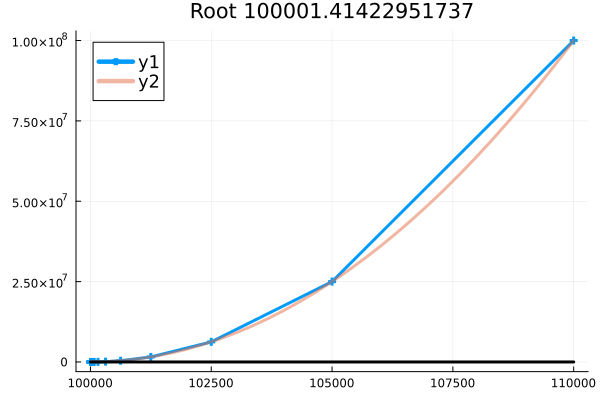

In [6]:
plot(hist[:,1], hist[:,2], seriestype=:path, marker=:auto)
plot!(g, title="Root $(hist[end,1])", alpha=.5)
plot!(zero, color=:black, label=:none)

* Convergence is kinda slow.
* The solution is not nearly as accurate as machine precision.

# Using `Polynomials`

Julia has a nice package to evaluate and manipulate polynomials. The coefficients are given in the other order $b_0 + b_1 x + b_2 x^2 + \dotsb$.

In [13]:
using Polynomials
@show fpoly = Polynomial([2, -3, 1])
@show gpoly = fromroots([1, 2] .+ 1e5)
derivative(gpoly)

fpoly = Polynomial([2, -3, 1]) = Polynomial(2 - 3*x + x^2)
gpoly = fromroots([1, 2] .+ 100000.0) = Polynomial(1.0000300002e10 - 200003.0*x + 1.0*x^2)


Polynomial(-200003.0 + 2.0*x)

In [14]:
newton_hist(gpoly, derivative(gpoly), 3e5)

24×3 Matrix{Float64}:
 300000.0            3.99994e10   399997.0
      2.00001e5      9.99985e9         1.99999e5
      1.50001e5      2.49996e9     99999.3
      1.25001e5      6.24991e8     49999.6
      1.12501e5      1.56248e8     24999.8
      1.06251e5      3.90619e7     12499.9
      1.03126e5      9.76548e6      6249.95
 101564.0            2.44137e6      3124.98
      1.00783e5      6.10342e5      1562.49
      1.00392e5      1.52586e5       781.245
      1.00197e5  38146.3             390.623
      1.00099e5   9536.52            195.313
      1.0005e5    2384.07             97.6589
      1.00026e5    595.954            48.8346
      1.00014e5    148.926            24.4275
      1.00008e5     37.1691           12.2342
      1.00005e5      9.2302            6.15799
      1.00003e5      2.2467            3.16019
      1.00002e5      0.505433          1.73831
      1.00002e5      0.0845417         1.15679
 100002.0            0.00534111        1.01063
 100002.0            2.79307

# Finding all roots of polynomials

In [17]:
roots(Polynomial([1e10, -2e5*(1 + 1e-10), 1]))

2-element Vector{Float64}:
  99998.58579643762
 100001.41422356237

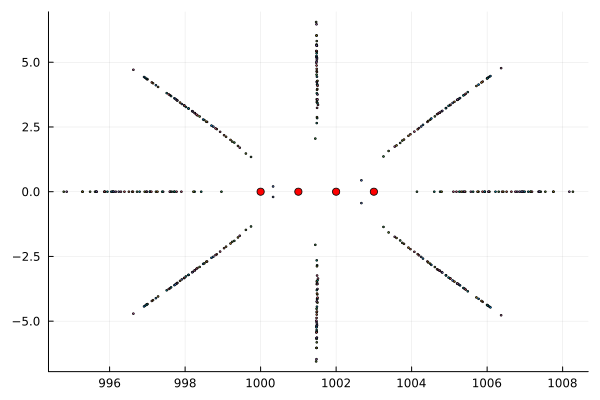

In [21]:
p = fromroots([0., 1., 2, 3] .+ 1000) # try a bigger translation
xs = roots(p)
scatter(real(xs), imag(xs), color=:red)
for i in 1:100
    r = randn(length(p)) # normally distributed mean 0, stddev 1
    q = copy(p)
    q[:] .*= 1 .+ 1e-10 * r
    xs = roots(q)
    scatter!(real(xs), imag(xs), markersize=1)
end
plot!(legend=:none)

> ## [Fundamental Theorem of Algebra](https://en.wikipedia.org/wiki/Fundamental_theorem_of_algebra)
>
> Every non-zero, single-variable, degree $n$ polynomial with complex coefficients has, counted with multiplicity, exactly $n$ complex roots.

# Wilkinson's polynomial

Suppose we add more terms
$$ w(x) = \prod_{k=1}^{20} (x - k) = (x - 1) (x - 2) \dotsb (x - 20) = \sum_{k=0}^{20} b_k x^k $$

In [11]:
n = 20
a = collect(1.:n)
w = fromroots(a)
w[10] *= 1 
plot(x -> abs(w(x)), xlims=(0, n+1), yscale=:log10)

LoadError: UndefVarError: `fromroots` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [12]:
w = fromroots(a)
scatter(a, zero(a), color=:red)
for i in 1:100
    r = randn(length(w))
    q = copy(w)
    q[:] .*= 1 .+ 1e-10 * r
    xs = roots(q)
    scatter!(real(xs), imag(xs), markersize=1)
end
plot!(legend=:none)

LoadError: UndefVarError: `fromroots` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

# Which is better to model inputs to a rootfinder?

* A: coefficients $a_k$ in $$p(x) = \prod_k (x - a_k)$$

* B: coefficients $b_k$ in $$p(x) = \sum_k b_k x^k$$

## Figure from Trefethen and Bau (1999)
<img alt="Ill conditioning of roots of Wilkinson's polynomial" src="../img/TB-Wilkinson.png" width="90%" />

# [Forward vs backward error and stability](https://fncbook.github.io/fnc/intro/stability.html#backward-error)

<img src="https://fncbook.com/build/backwarderror-55621e558c526e24b8fc1d61b00b65a3.svg" width="90%" />

## Stability
**"nearly the right answer to nearly the right question"**
$$ \frac{\lvert \tilde f(x) - f(\tilde x) \rvert}{| f(\tilde x) |} \in O(\epsilon_{\text{machine}}) $$
for some $\tilde x$ that is close to $x$

## Backward Stability
**"exactly the right answer to nearly the right question"**
$$ \tilde f(x) = f(\tilde x) $$
for some $\tilde x$ that is close to $x$

* Every backward stable algorithm is stable.
* Not every stable algorithm is backward stable.